# Versão 3 - Visão Geral dos Dados

Este notebook é a porta de entrada do pipeline. Antes de treinar qualquer modelo de séries temporais, precisamos entender o que existe no dataset 3W, como as séries estão distribuídas e quais dificuldades práticas podem aparecer no treinamento.

Ao longo desta leitura, a ideia é responder cinco perguntas:
1. quantos arquivos e classes existem
2. como esses arquivos se distribuem entre poços reais, séries simuladas e séries desenhadas
3. qual é o tamanho típico de cada série temporal
4. quanto dado ausente aparece em média
5. quais sinais sugerem desafios para as próximas etapas do pipeline

## 1.Preparação do ambiente

Primeiro carregamos bibliotecas de visualização e funções auxiliares do arquivo `pipeline_v3.py`. Esse arquivo concentra operações repetidas, como descobrir arquivos do dataset e ler cada série com a coluna de tempo corretamente ordenada.

In [1]:
from __future__ import annotations

#resolve caminhos de forma robusta para que o notebook funcione tanto na raiz do projeto quanto dentro da pasta versao3
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
CANDIDATE_DIRS = [
    CURRENT_DIR,
    CURRENT_DIR / "versao3",
    CURRENT_DIR.parent / "versao3",
]
NOTEBOOK_DIR = next((candidate for candidate in CANDIDATE_DIRS if (candidate / "pipeline_v3.py").exists()), CURRENT_DIR)
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

#carrega bibliotecas para tabelas e graficos
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

#importa funcoes auxiliares do pipeline
from pipeline_v3 import discover_all_dataset_files, read_parquet_with_timestamp, set_seed

#fixa a aleatoriedade para manter a reproducibilidade das amostras e graficos
set_seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

## 2.Localização do dataset e criação do manifesto

O manifesto é uma tabela-resumo em que cada linha representa uma série temporal do dataset. Ele não carrega todos os valores numéricos ainda; apenas registra onde cada arquivo está e quais metadados básicos ele carrega no nome e na pasta.

In [2]:
#descobre a raiz do projeto para localizar a pasta 3W/dataset
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in {"versao1", "versao2", "versao3"} else CURRENT_DIR
DATASET_ROOT = PROJECT_ROOT / "3W" / "dataset"

#cria o manifesto com uma linha por arquivo da base
manifest_df = discover_all_dataset_files(DATASET_ROOT)
manifest_df.head()

,class_label,well_name,start_token,series_id,source_type,file_path
0,0,WELL-00001,20170201010207,0__WELL-00001_20170201010207,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
1,0,WELL-00001,20170201060114,0__WELL-00001_20170201060114,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
2,0,WELL-00001,20170201110124,0__WELL-00001_20170201110124,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
3,0,WELL-00001,20170201160311,0__WELL-00001_20170201160311,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
4,0,WELL-00001,20170201210228,0__WELL-00001_20170201210228,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...


A prévia acima mostra a estrutura básica de cada série:

- `class_label`: a classe do evento no dataset 3W
- `well_name`: o poço ou a origem da série
- `series_id`: identificador único usado ao longo do pipeline
- `source_type`: se a série vem de poço real, simulação ou desenho manual
- `file_path`: caminho completo do arquivo `.parquet`

Essa tabela é importante porque ela vira a referência para divisão em treino, validação e teste nas próximas etapas.

In [3]:
#resume o tamanho geral da base para enxergar a escala do problema
overview_df = pd.DataFrame(
    {
        "aspecto": [
            "arquivos_totais",
            "classes_distintas",
            "wells_distintos",
            "tipos_de_origem",
        ],
        "valor": [
            int(len(manifest_df)),
            int(manifest_df["class_label"].nunique()),
            int(manifest_df["well_name"].nunique()),
            int(manifest_df["source_type"].nunique()),
        ],
    }
)

#conta quantos arquivos existem por classe e por tipo de origem
class_counts_df = manifest_df["class_label"].value_counts().sort_index().rename_axis("class_label").reset_index(name="arquivos")
source_counts_df = manifest_df["source_type"].value_counts().rename_axis("source_type").reset_index(name="arquivos")

#mede quantos arquivos cada poço contribui em cada classe
files_per_well_df = (
    manifest_df.groupby(["class_label", "well_name"], as_index=False)
    .size()
    .rename(columns={"size": "arquivos"})
    .sort_values("arquivos", ascending=False)
)

display(overview_df)
display(class_counts_df)
display(source_counts_df)
files_per_well_df.head(20)

,aspecto,valor
0,arquivos_totais,2228
1,classes_distintas,10
2,wells_distintos,42
3,tipos_de_origem,3


,class_label,arquivos
0,0,594
1,1,128
2,2,38
3,3,106
4,4,343
5,5,450
6,6,221
7,7,46
8,8,95
9,9,207


,source_type,arquivos
0,well,1119
1,simulated,1089
2,drawn,20


,class_label,well_name,arquivos
32,5,SIMULATED,439
36,6,SIMULATED,215
1,0,WELL-00002,209
56,9,SIMULATED,150
10,1,SIMULATED,114
5,0,WELL-00006,113
26,4,WELL-00002,112
0,0,WELL-00001,93
30,4,WELL-00010,83
4,0,WELL-00005,81


### Como interpretar esses totais

Os resultados já mostram três fatos importantes:

1. existem **2228 arquivos** distribuídos em **10 classes**, o que é suficiente para um experimento supervisionado, mas não garante equilíbrio entre classes.
2. a distribuição é **desbalanceada**: a classe `0` tem 594 arquivos, enquanto a classe `2` tem apenas 38. Em Machine Learning isso importa porque o modelo pode aprender melhor as classes mais frequentes.
3. há **três tipos de origem**. Isso é útil porque dados reais, simulados e desenhados podem ter comportamentos diferentes, o que afeta generalização e interpretação dos resultados.

Também vale notar que alguns poços e grupos simulados concentram muitos arquivos. Isso sugere cautela ao dividir treino, validação e teste, para evitar vazamento de informação entre conjuntos muito parecidos.

## 3.Perfil temporal de cada série

Agora saímos do nível “um arquivo por linha” e olhamos o conteúdo temporal de cada série. O objetivo é medir tamanho, duração, intervalo de tempo e porcentagem média de valores ausentes.

In [4]:
#cria uma lista com estatisticas por serie para entender tamanho, duracao e faltas de dados
profile_rows = []
for row in manifest_df.itertuples(index=False):
    #le o arquivo parquet e garante que a coluna timestamp esteja ordenada corretamente
    frame = read_parquet_with_timestamp(row.file_path)
    profile_rows.append(
        {
            "series_id": row.series_id,
            "class_label": row.class_label,
            "well_name": row.well_name,
            "source_type": row.source_type,
            "rows": len(frame),
            "columns": len(frame.columns),
            "start": frame["timestamp"].min(),
            "end": frame["timestamp"].max(),
            "duration_hours": float((frame["timestamp"].max() - frame["timestamp"].min()).total_seconds() / 3600.0) if len(frame) > 1 else 0.0,
            "missing_pct": float(frame.isna().mean().mean() * 100),
        }
    )

#organiza o perfil para facilitar a leitura nas tabelas seguintes
profile_df = pd.DataFrame(profile_rows).sort_values(["class_label", "well_name", "series_id"]).reset_index(drop=True)
profile_df.head()

,series_id,class_label,well_name,source_type,rows,columns,start,end,duration_hours,missing_pct
0,0__WELL-00001_20170201010207,0,WELL-00001,well,21474,30,2017-02-01 01:02:07,2017-02-01 07:00:00,5.964722,31.117631
1,0__WELL-00001_20170201060114,0,WELL-00001,well,21527,30,2017-02-01 06:01:14,2017-02-01 12:00:00,5.979444,31.114879
2,0__WELL-00001_20170201110124,0,WELL-00001,well,21517,30,2017-02-01 11:01:24,2017-02-01 17:00:00,5.976667,31.115397
3,0__WELL-00001_20170201160311,0,WELL-00001,well,21410,30,2017-02-01 16:03:11,2017-02-01 22:00:00,5.946944,31.120972
4,0__WELL-00001_20170201210228,0,WELL-00001,well,21453,30,2017-02-01 21:02:28,2017-02-02 03:00:00,5.958889,31.118725


A amostra acima mostra que uma série individual pode ter dezenas de milhares de linhas e cobrir várias horas de operação. Esse ponto é central para séries temporais: quanto maior a sequência, maior a quantidade de possíveis janelas de treino e teste que podemos gerar.

Em outras palavras, o número de arquivos não conta toda a história. Mesmo com “apenas” 2228 séries, o número de exemplos derivados delas pode ser gigantesco.

In [5]:
#agrega as estatisticas por classe e por tipo de origem para comparar grupos inteiros
aggregate_profile_df = (
    profile_df.groupby(["class_label", "source_type"], as_index=False)
    .agg(
        arquivos=("series_id", "count"),
        linhas_totais=("rows", "sum"),
        linhas_medias=("rows", "mean"),
        duracao_media_horas=("duration_hours", "mean"),
        missing_pct_medio=("missing_pct", "mean"),
    )
    .sort_values(["class_label", "source_type"])
)

#verifica em quantas series e em quantas classes cada coluna aparece
feature_presence_df = []
for row in manifest_df.itertuples(index=False):
    frame = read_parquet_with_timestamp(row.file_path)
    for column in frame.columns:
        feature_presence_df.append(
            {
                "column": column,
                "series_id": row.series_id,
                "class_label": row.class_label,
            }
        )
feature_presence_df = pd.DataFrame(feature_presence_df)
feature_coverage_df = (
    feature_presence_df.groupby("column", as_index=False)
    .agg(series_com_coluna=("series_id", "nunique"), classes_com_coluna=("class_label", "nunique"))
    .sort_values(["series_com_coluna", "column"], ascending=[False, True])
)

display(aggregate_profile_df)
feature_coverage_df.head(30)

,class_label,source_type,arquivos,linhas_totais,linhas_medias,duracao_media_horas,missing_pct_medio
0,0,well,594,12158183,20468.321549,5.685367,55.286221
1,1,drawn,10,547200,54720.000000,15.199722,73.333333
2,1,simulated,114,8323113,73009.763158,20.280212,73.333333
3,1,well,4,236794,59198.500000,16.443750,42.262096
4,2,simulated,16,460784,28799.000000,7.999444,73.333333
5,2,well,22,277001,12590.954545,3.497210,68.053630
6,3,simulated,74,4264927,57634.148649,16.009208,73.333333
7,3,well,32,684352,21386.000000,5.940278,44.153284
8,4,well,343,3689683,10757.093294,2.987804,59.281009
9,5,simulated,439,12862269,29299.018223,8.138338,66.666667


,column,series_com_coluna,classes_com_coluna
0,ABER-CKGL,2228,10
1,ABER-CKP,2228,10
2,ESTADO-DHSV,2228,10
3,ESTADO-M1,2228,10
4,ESTADO-M2,2228,10
5,ESTADO-PXO,2228,10
6,ESTADO-SDV-GL,2228,10
7,ESTADO-SDV-P,2228,10
8,ESTADO-W1,2228,10
9,ESTADO-W2,2228,10


### Leituras importantes desta etapa

- as classes simuladas costumam ter **percentual médio de faltas muito alto**, frequentemente próximo de 66% a 73%.
- algumas classes reais têm séries muito longas, como as classes `7`, `8` e `9`, o que ajuda a explicar por que o número de janelas cresce rapidamente no treino e no teste.
- a tabela de cobertura mostra que as colunas principais aparecem em todas as séries e em todas as classes. Isso é ótimo porque reduz o risco de termos uma feature “quebrando” em uma parte da base.

Para um aluno iniciante, esse é um ponto-chave: antes de treinar um modelo, precisamos saber se os dados estão completos, equilibrados e comparáveis entre si.

## 4.Visualização rápida dos padrões globais

As figuras abaixo ajudam a resumir visualmente o que as tabelas já sugerem: desbalanceamento entre classes, mistura de origens e grande variabilidade no tamanho das séries.

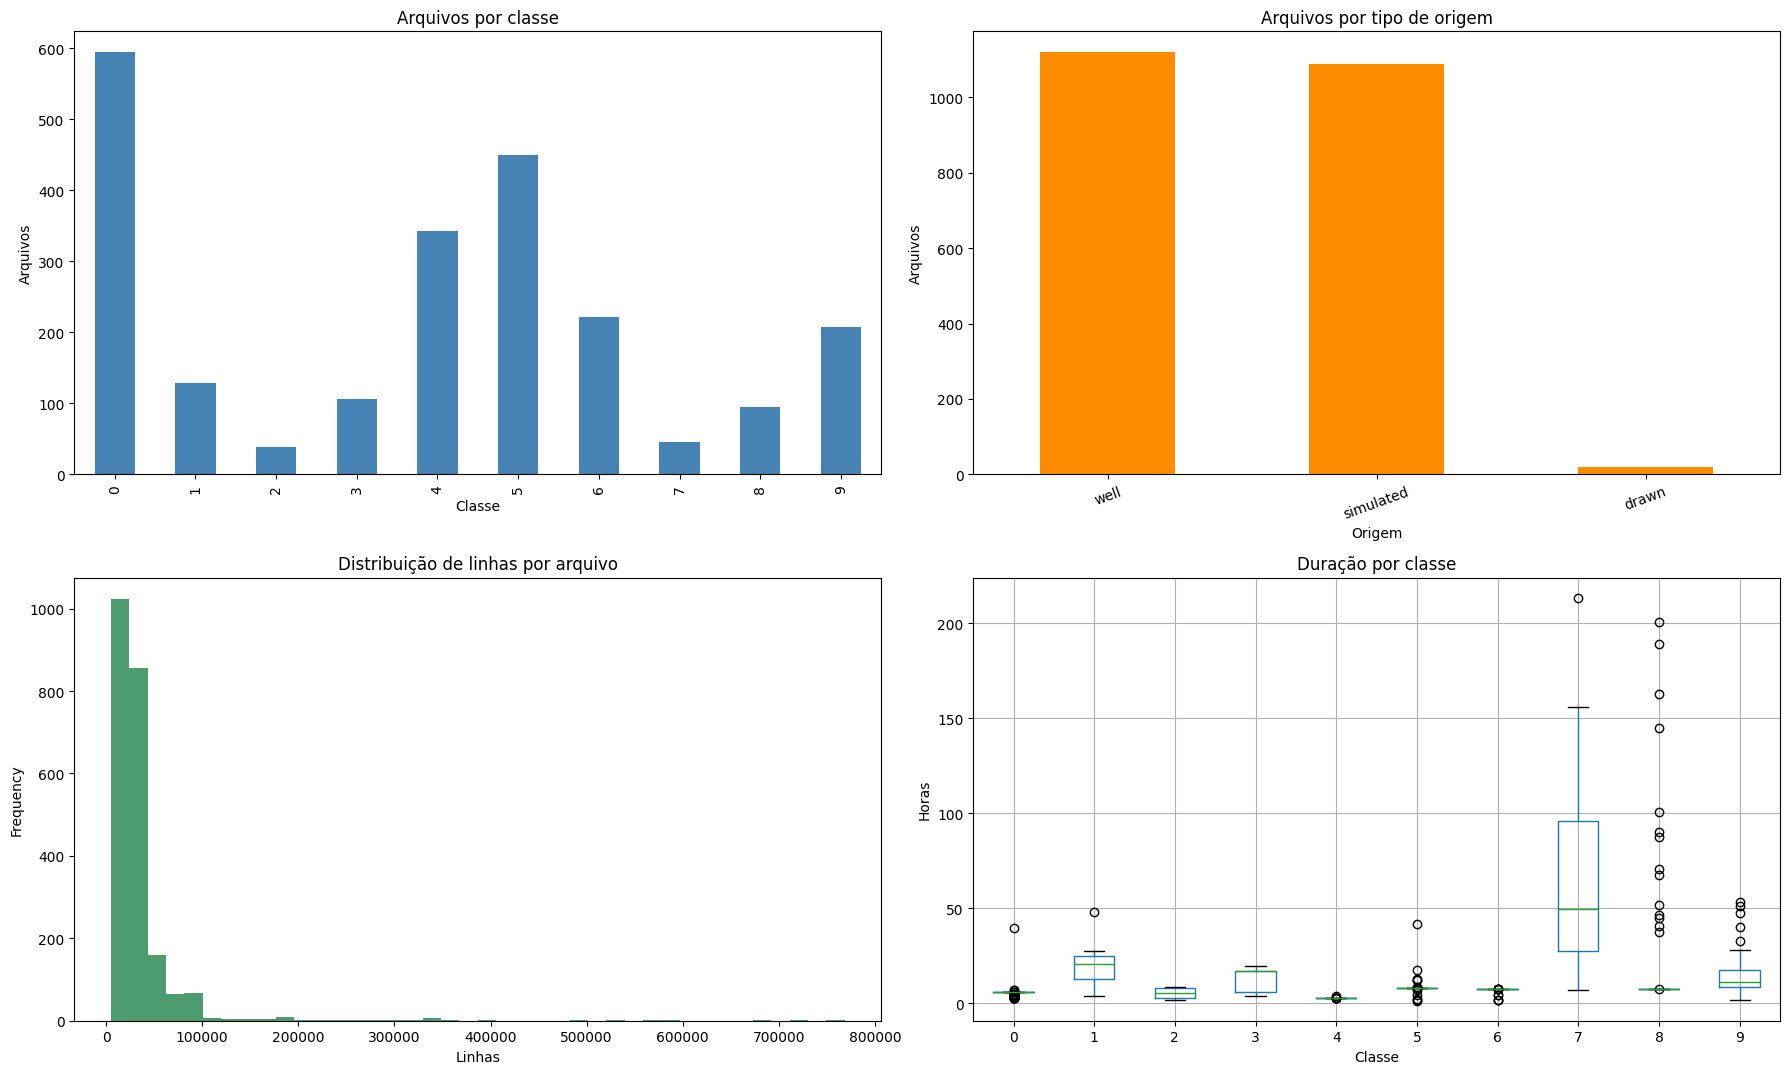

In [6]:
#gera graficos simples para comparar distribuicoes sem precisar ler a tabela inteira
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

#grafico de barras com o total de arquivos por classe
class_counts_df.plot(kind="bar", x="class_label", y="arquivos", ax=axes[0, 0], legend=False, color="steelblue")
axes[0, 0].set_title("Arquivos por classe")
axes[0, 0].set_xlabel("Classe")
axes[0, 0].set_ylabel("Arquivos")

#grafico de barras com o total de arquivos por origem
source_counts_df.plot(kind="bar", x="source_type", y="arquivos", ax=axes[0, 1], legend=False, color="darkorange")
axes[0, 1].set_title("Arquivos por tipo de origem")
axes[0, 1].set_xlabel("Origem")
axes[0, 1].set_ylabel("Arquivos")
axes[0, 1].tick_params(axis="x", rotation=20)

#histograma do numero de linhas por arquivo
profile_df["rows"].plot(kind="hist", bins=40, ax=axes[1, 0], color="seagreen", alpha=0.85)
axes[1, 0].set_title("Distribuição de linhas por arquivo")
axes[1, 0].set_xlabel("Linhas")

#boxplot da duracao por classe para enxergar dispersao e valores extremos
profile_df.boxplot(column="duration_hours", by="class_label", ax=axes[1, 1])
axes[1, 1].set_title("Duração por classe")
axes[1, 1].set_xlabel("Classe")
axes[1, 1].set_ylabel("Horas")
plt.suptitle("")

plt.tight_layout()
plt.show()

Se os gráficos mostrarem barras muito diferentes entre classes, isso confirma o desbalanceamento observado nas tabelas. Se o histograma de linhas for muito espalhado, significa que algumas séries são muito curtas e outras muito longas, o que complica a escolha de um tamanho fixo de sequência para o modelo.

Já o boxplot de duração ajuda a perceber se certas classes tendem a durar muito mais tempo. Isso pode ser uma pista de que alguns eventos têm dinâmica temporal própria.

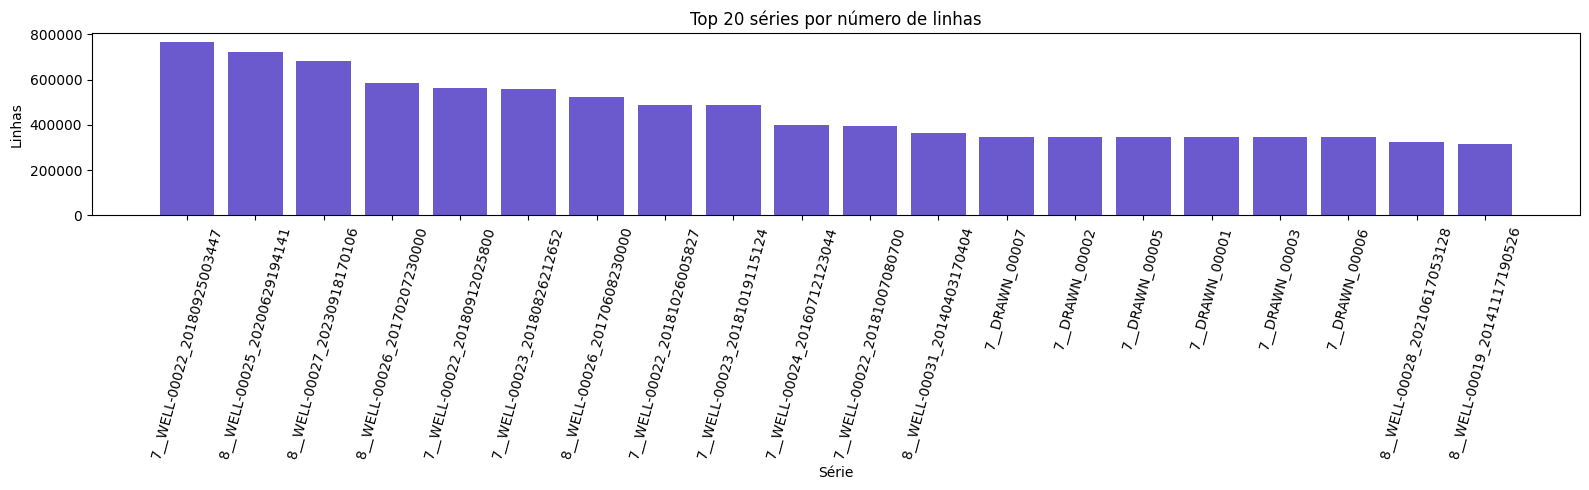

In [7]:
#destaca as series mais longas para deixar explicito quais arquivos mais influenciam o volume total de dados
top_series_df = profile_df.sort_values("rows", ascending=False).head(20)
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(top_series_df["series_id"], top_series_df["rows"], color="slateblue")
ax.set_title("Top 20 séries por número de linhas")
ax.set_xlabel("Série")
ax.set_ylabel("Linhas")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

## Conclusão da etapa

A leitura exploratória deixa duas mensagens muito importantes para o restante do projeto:

- o dataset é rico, mas **heterogêneo**: há classes raras, séries de durações muito diferentes e bastante dado faltante em alguns grupos;
- o número de exemplos derivados das séries pode ficar enorme, então as próximas etapas precisam ser cuidadosas com normalização, geração de features e uso de memória.

No próximo notebook, essas observações se transformam em decisões de pré-processamento.